In [60]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import copy
import seaborn as sns

In [61]:
print(pd.__version__)

2.3.0


In [62]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Nimbus Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [63]:
def get_shap_average(shap_impact_list):
    
    dy_dict = {0:[],
               1:[],
               2:[],
               3:[],
               4:[]}
    ba_list = []
    for i in shap_impact_list:
        dy = i[0]
        ba = i[1]
        ba['SHAP'] = ba['SHAP_abs'].abs() * np.sign(ba['Corr'])
        ba = ba[['Variable', 'SHAP']]
        ba = ba.set_index('Variable', drop=True)
        ba = ba.sort_index()
        ba_list.append(ba)
    
        for j in range(5):
            t = dy[j]
            t = t[['Variable', 'SHAP_abs', 'Corr']]
            t['SHAP'] = t['SHAP_abs'].abs() * np.sign(t['Corr'])
            t = t[['Variable', 'SHAP']]
            t = t.set_index('Variable', drop=True)
            t = t.sort_index()
            dy_dict[j].append(copy.deepcopy(t))
            
    shap_dy = []    
    for k in range(5):
        temp = sum(dy_dict[k]) / len(dy_dict[k])
        temp = temp.reset_index()
        # temp['Sign'] = np.where(temp['Corr'] <= 0, 'silver', 'mediumseagreen')
        shap_dy.append(copy.deepcopy(temp))
    shap_ba = sum(ba_list) / len(ba_list)
    shap_ba = shap_ba.reset_index()
    # shap_ba['Sign'] = np.where(shap_c_ba['Corr'] <= 0, 'silver', 'mediumseagreen')

    return shap_dy, shap_ba

In [64]:
def sum_across_dfs(dfs, fill_value=0):
    """
    Align on `key` (defaults to the first column of dfs[0]) and
    elementwise-sum the remaining columns across all DataFrames.
    """
    aligned = []
    for df in dfs:
        df = df.set_index('Variable',  drop=True)
        df = df.sort_index()
        aligned.append(copy.deepcopy(df))
    
    # Start with zeros, then add each DF
    total = aligned[0]
    for a in aligned[1:]:
        total = total.add(a, fill_value=fill_value)

    return total.reset_index()

def get_top_dy_var(dfs, n):
    shap_dy_all = sum_across_dfs(dfs)
    shap_dy_all['abs'] = shap_dy_all['SHAP'].abs()
    shap_dy_all = shap_dy_all.sort_values(by='abs', ascending=False)
    var_dy = list(shap_dy_all.head(n).Variable)

    return var_dy

In [65]:
def get_df(impact_list, var):
    df_ = pd.DataFrame(columns = ['var'])
    for i in range(5):
        df = impact_list[i]
        tdf = copy.deepcopy(df[df['Variable'].isin(var)])
        tdf = tdf[['Variable', 'SHAP']]
        s = 'SHAP' + str(i)
        tdf.columns = ['var', s]
        df_ = df_.merge(tdf, on='var', how='outer')

    df_ = df_.set_index('var')
    
    return df_

In [66]:
def get_final(df, df_bg):
    df = df[['SHAP0', 'SHAP1', 'SHAP2', 'SHAP3', 'SHAP4']]

    df_bg_t = copy.deepcopy(df_bg)
    df_bg_t['SHAP_abs'] = df_bg_t['SHAP'].abs()
    df_bg_t = df_bg_t.sort_values(by='SHAP_abs', ascending=False)
    df_bg_t =df_bg_t.head(len(df))
    df_bg_t = df_bg_t[['Variable', 'SHAP']]
    df_bg_t =  df_bg_t.sort_values(by='SHAP', ascending=False)
    df_bg_t = df_bg_t.set_index('Variable')

    df = df.sort_values(by='SHAP4', ascending=False)
    return df, df_bg_t

In [67]:
T_shap = '../results/data/tmodel/shap_impact_list.pkl'
C_shap = '../results/data/cmodel/shap_impact_list.pkl'
M_shap = '../results/data/mix/shap_impact_list.pkl'

T_dir = '../results/figures/tmodel/'
C_dir = '../results/figures/cmodel/'
M_dir = '../results/figures/mix/'

In [68]:
with open(T_shap, 'rb') as f:
     shap_impact_list_t = pickle.load(f)

In [69]:
with open(C_shap, 'rb') as f:
     shap_impact_list_c = pickle.load(f)

In [70]:
with open(M_shap, 'rb') as f:
     shap_impact_list_m = pickle.load(f)

In [71]:
shap_m_dy, shap_m_ba = get_shap_average(shap_impact_list_m)
shap_c_dy, shap_c_ba = get_shap_average(shap_impact_list_c)
shap_t_dy, shap_t_ba = get_shap_average(shap_impact_list_t)

In [72]:
n=20

In [73]:
var_t_dy = get_top_dy_var(shap_t_dy, n)
var_c_dy = get_top_dy_var(shap_c_dy, n)
var_m_dy = get_top_dy_var(shap_m_dy, n)

In [74]:
df_t_dy = get_df(shap_t_dy, var_t_dy)
df_c_dy = get_df(shap_c_dy, var_c_dy)
df_m_dy = get_df(shap_m_dy, var_m_dy)

In [75]:
df_t_dy, df_t_ba= get_final(df_t_dy, shap_t_ba)
df_c_dy, df_c_ba= get_final(df_c_dy, shap_c_ba)
df_m_dy, df_m_ba= get_final(df_m_dy, shap_m_ba)

In [76]:
mapping = {'HgB':'Hemoglobin',
           'Hct':'Hematocrit',
           'RDW': 'RedCellDistributionWidth',
           'MCHC': 'MeanCorpuscularHgbConcentrn',
           'RBC': 'RedBloodCellCount',
           'BMI_CAL_weights_and': 'BMI_Calculation:kg/m2',
           'BUN': 'BloodUreaNitrogen',
           'MOST_R_D':'MostRecentBloodTransfusionDate',
           'BloodChem_TM': 'BloodChemistryTime',
           'PulseO2Sat_monitor': 'IntermittentPulseOxygenSaturation',
           'Measure_TM': 'BloodPressureExamTime',
           'MCV':'MeanCorpuscularVolume',
           'MCH':'MeanCorpuscularHemoglobin',
           'BMI_weights_and':'BMI',
           'WBC':'WhiteBloodCellCount',
           'PLT':'PlateletCount',
           'MPV':'MeanPlateletVolume',
           'EVER_BT':'EverBloodTrans',
           'Cohort_Event':'CohortEventBloodChemistry',
           'ALB_LVL':'AlbuminLevel',
           'HT_weights_and': 'Height'
           }
df_t_dy.index = df_t_dy.index.map(lambda x: str(x).rsplit("_", 1)[0])
df_t_dy = df_t_dy.rename(index=mapping)

In [77]:
df_c_dy.index = df_c_dy.index.map(lambda x: str(x).rsplit("_", 1)[0])
df_c_dy = df_c_dy.rename(index=mapping)

df_m_dy.index = df_m_dy.index.map(lambda x: str(x).rsplit("_", 1)[0])
df_m_dy = df_m_dy.rename(index=mapping)

In [78]:
mapping_ba = {'Age_2021_demographic': 'Age_at_2021',
              'Age_Crizanzumab_crizanzumab': 'Age_at_Crizanzumab',
              'Age_LGluatmine_l_gluatmine': 'Age_at_L-glutamine',
              'Age_at_CTXN_ctxn': 'Age_at_CTXN',
              'BMT_othertreatment_summary':'BoneMarrowTransplantSummary',
              'CTXN_Duration1_ctxn':'1stCTXN_Duration',
              'CTXN_Duration2_ctxn':'2ndCTXN_Duration',
              'CTXN_Duration3_ctxn':'3rdCTXN_Duration',
              'Cohort_21Freeze_demographic':'Cohort_at_2021',
              'Crizan_END_DT_crizanzumab':'CrizanlizumabEndDate',
              'Crizan_Start_DT_crizanzumab':'CrizanlizumabStartDate',
              'Crizanzumab_othertreatment_summary':'CrizanlizumabSummary',
              'Ethnicity_demographic':'Ethnicity',
              'Follow_interval_demographic':'FollowUpInterval(days)',
              'Gender_demographic':'Gender',
              'Genotype_demographic':'Genotype',
              'LG_END_DT_l_gluatmine':'L-glutamineEndDate',
              'LG_Start_DT_l_gluatmine':'L-glutamineStartDate',
              'L_Glut_othertreatment_summary':'L-glutamineSummary',
              'Other_treat_othertreatment_summary':'OtherTreatmentSummary',
              'Race_demographic':'Race',
              'Voxelotor_othertreatment_summary':'VoxelotorSummary',
              'Zip_code_demographic':'Zipcode'}

df_t_ba = df_t_ba.rename(index=mapping_ba)
df_c_ba = df_c_ba.rename(index=mapping_ba)
df_m_ba = df_m_ba.rename(index=mapping_ba)

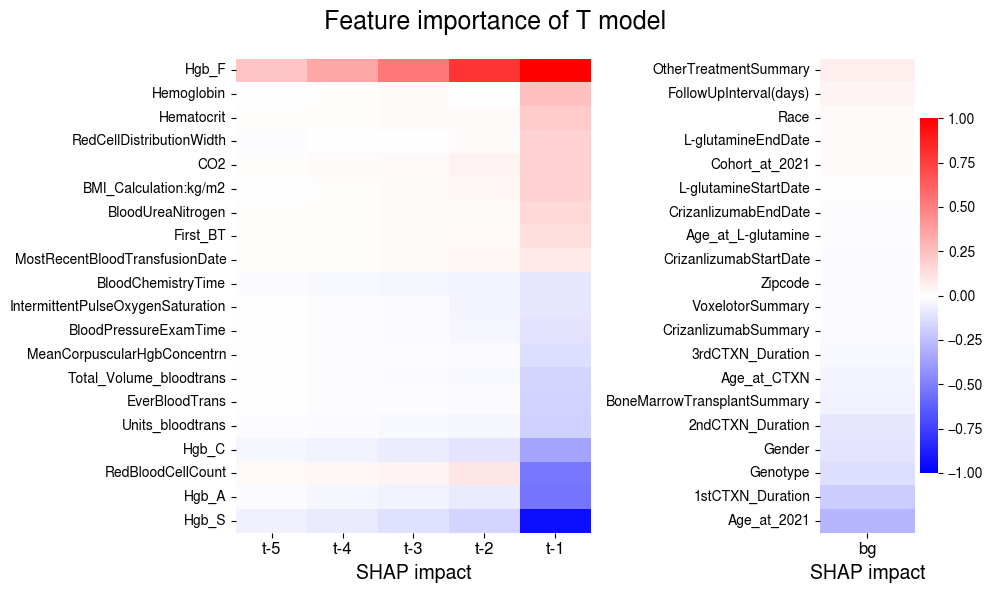

In [79]:
fig, ax= plt.subplots(nrows=1, ncols=2, figsize=(10,6), gridspec_kw={'width_ratios': [3, 1]})   # The big subplot

ax1, ax2 = ax.flatten()
sns.heatmap(df_t_dy, cmap='bwr', vmin=-1, vmax=1,cbar=False, ax=ax1)
sns.heatmap(df_t_ba, cmap='bwr', vmin=-1, vmax=1, ax=ax2)
ax1.set_xticklabels(['t-5','t-4','t-3','t-2','t-1'], fontsize=12)
ax2.set_xticklabels(['bg'], fontsize=12)
ax1.set_ylabel('')
ax2.set_ylabel('')
ax1.set_xlabel('SHAP impact', fontsize=14)
ax2.set_xlabel('SHAP impact', fontsize=14)

fig.suptitle('Feature importance of T model', fontsize=18)
plt.tight_layout()
# plt.savefig(T_dir + 'shap_heatmap.pdf')

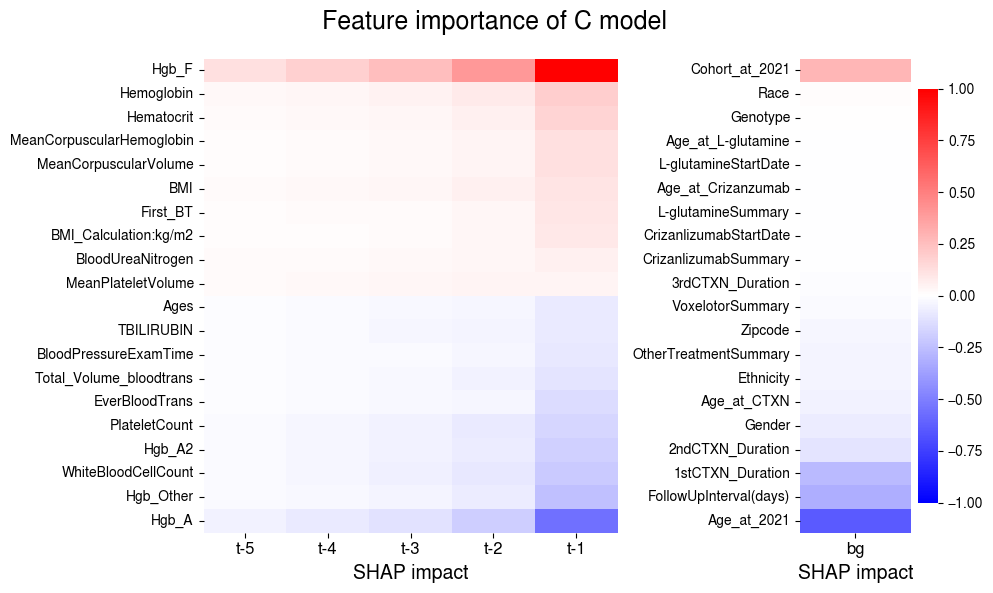

In [80]:
fig, ax= plt.subplots(nrows=1, ncols=2, figsize=(10,6), gridspec_kw={'width_ratios': [3, 1]})   # The big subplot

ax1, ax2 = ax.flatten()
sns.heatmap(df_c_dy, cmap='bwr', vmin=-1, vmax=1,cbar=False, ax=ax1)
sns.heatmap(df_c_ba, cmap='bwr', vmin=-1, vmax=1, ax=ax2)
ax1.set_xticklabels(['t-5','t-4','t-3','t-2','t-1'], fontsize=12)
ax2.set_xticklabels(['bg'], fontsize=12)
ax1.set_ylabel('')
ax2.set_ylabel('')
ax1.set_xlabel('SHAP impact', fontsize=14)
ax2.set_xlabel('SHAP impact', fontsize=14)

fig.suptitle('Feature importance of C model', fontsize=18)
plt.tight_layout()
# plt.savefig(C_dir + 'shap_heatmap.pdf')

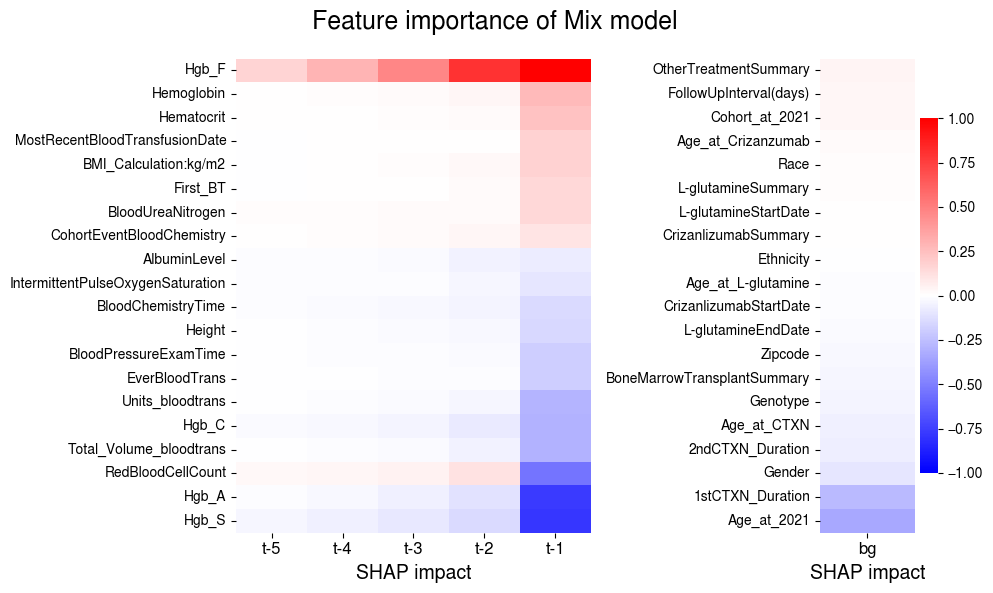

In [81]:
fig, ax= plt.subplots(nrows=1, ncols=2, figsize=(10,6), gridspec_kw={'width_ratios': [3, 1]})   # The big subplot

ax1, ax2 = ax.flatten()
sns.heatmap(df_m_dy, cmap='bwr', vmin=-1, vmax=1,cbar=False, ax=ax1)
sns.heatmap(df_m_ba, cmap='bwr', vmin=-1, vmax=1, ax=ax2)
ax1.set_xticklabels(['t-5','t-4','t-3','t-2','t-1'], fontsize=12)
ax2.set_xticklabels(['bg'], fontsize=12)
ax1.set_ylabel('')
ax2.set_ylabel('')
ax1.set_xlabel('SHAP impact', fontsize=14)
ax2.set_xlabel('SHAP impact', fontsize=14)

fig.suptitle('Feature importance of Mix model', fontsize=18)
plt.tight_layout()
# plt.savefig(M_dir + 'shap_heatmap.pdf')